# Detection Metrics Dashboard

This notebook loads the JSON summaries produced by the benchmark (`experiments/compute_metrics.py`) and creates publication-ready plots:

- COCO-style AP (IoU 0.50:0.95) and AP@0.5 for both traditional and VLM models.
- Latency statistics (mean, median, p95) visualized side-by-side.
- Optional long-tail breakdown for LVIS unseen categories.

## Usage
1. Ensure you have run the evaluation script:
   ```bash
   python experiments/compute_metrics.py --dataset all > results/metrics_summary.json
   ```
   Alternatively, adapt the `SUMMARY_FILE` path in the next cell to point to your summary JSON.
2. Execute this notebook to generate plots for the paper.

The notebook assumes you are running inside the project root directory.

In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline
sns.set_theme(style="whitegrid", context="paper", font_scale=1.2)

PROJECT_ROOT = Path.cwd()
SUMMARY_FILE = Path('../results') / "metrics_summary.json"
if not SUMMARY_FILE.exists() or SUMMARY_FILE.stat().st_size == 0:
    raise FileNotFoundError("Summary file not found or empty. Run \"python experiments/compute_metrics.py --dataset all > results/metrics_summary.json\" first.")


In [2]:
def save_figure(fig, name: str, output_dir: Path = PROJECT_ROOT / "results" / "figures"):
    output_dir.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig_path = output_dir / f"{name}.{ext}"
        fig.savefig(fig_path, bbox_inches="tight")
        print(f"Saved: {fig_path}")

def load_summary(summary_path: Path) -> pd.DataFrame:
    """Load the JSON summary into a tidy DataFrame."""
    try:
        with summary_path.open('r', encoding='utf-8') as fh:
            data = json.load(fh)
    except json.JSONDecodeError as exc:
        raise ValueError('Failed to parse metrics summary JSON. Ensure the file contains valid JSON.') from exc

    records = []
    for dataset, entries in data.items():
        for model_info in entries:
            record = {
                'dataset': dataset,
                'model': model_info['model'],
                'family': model_info.get('family', 'unknown'),
                'AP': model_info.get('ap'),
                'AP50': model_info.get('ap50'),
                'latency_mean': model_info.get('latency_mean'),
                'latency_median': model_info.get('latency_median'),
                'latency_p95': model_info.get('latency_p95'),
                'label_accuracy': model_info.get('label_accuracy'),
            }
            records.append(record)
    df = pd.DataFrame(records)
    df = df.sort_values(['dataset', 'family', 'model']).reset_index(drop=True)
    return df


metrics_df = load_summary(SUMMARY_FILE)
metrics_df.head()


,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
0,lvis-unseen,grounding_dino,traditional,0.267228,0.311766,0.292924,0.287225,0.319239,0.966887
1,lvis-unseen,owl_vit,traditional,0.141849,0.223416,0.080768,0.080208,0.085718,0.963576
2,lvis-unseen,yolo_world,traditional,0.220512,0.264980,0.047127,0.034645,0.039222,0.981651
3,lvis-unseen,claude-haiku-4.5,vlm,0.001469,0.009088,2.474337,2.474337,2.835362,0.922388
4,lvis-unseen,claude-opus-4.8,vlm,0.125929,0.315990,3.878640,3.878640,5.049952,0.966667


In [3]:
def plot_bar_metric(df: pd.DataFrame, metric: str, title: str, ylabel: str, figsize=(10, 6)):
    """Render a horizontal bar chart comparing models on a given metric."""
    if metric not in df.columns:
        return None, None
    subset = df.dropna(subset=[metric])
    if subset.empty:
        return None, None
    fig, ax = plt.subplots(figsize=figsize)
    order = subset.sort_values(metric, ascending=False)
    palette = sns.color_palette('Set2', n_colors=subset['family'].nunique())
    sns.barplot(
        data=order,
        y='model',
        x=metric,
        hue='family',
        dodge=False,
        palette=palette,
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel(ylabel)
    ax.set_ylabel('Model')
    ax.legend(title='Family', loc='lower right')
    ax.set_xlim(left=0)
    sns.despine(ax=ax)

    save_figure(fig, name=title.replace(' ', '_'))
    
    return fig, ax


def plot_latency_box(df: pd.DataFrame, title: str, figsize=(10, 6)):
    """Generate a bar plot of latency statistics (mean/median/p95)."""
    melted = df.melt(
        id_vars=['dataset', 'model', 'family'],
        value_vars=['latency_mean', 'latency_median', 'latency_p95'],
        var_name='latency_stat',
        value_name='seconds',
    )
    melted = melted.dropna(subset=['seconds'])
    if melted.empty:
        return None, None
    fig, ax = plt.subplots(figsize=figsize)
    sns.barplot(
        data=melted,
        x='seconds',
        y='model',
        hue='latency_stat',
        palette='Blues',
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel('Latency (s)')
    ax.set_ylabel('Model')
    ax.legend(title='Statistic', loc='upper right')
    ax.set_xlim(left=0)
    sns.despine(ax=ax)

    save_figure(fig, name=title.replace(' ', '_'))
    return fig, ax


,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
0,lvis-unseen,grounding_dino,traditional,0.267228,0.311766,0.292924,0.287225,0.319239,0.966887
1,lvis-unseen,owl_vit,traditional,0.141849,0.223416,0.080768,0.080208,0.085718,0.963576
2,lvis-unseen,yolo_world,traditional,0.220512,0.264980,0.047127,0.034645,0.039222,0.981651
3,lvis-unseen,claude-haiku-4.5,vlm,0.001469,0.009088,2.474337,2.474337,2.835362,0.922388
4,lvis-unseen,claude-opus-4.8,vlm,0.125929,0.315990,3.878640,3.878640,5.049952,0.966667
5,lvis-unseen,gemini-3.1-pro,vlm,0.564990,0.675897,2.913171,2.913171,3.511172,0.992574
6,lvis-unseen,gemini-3.5-flash,vlm,0.606566,0.726438,4.777280,4.777280,5.515134,0.997506
7,lvis-unseen,gemma-3-27b-openrouter,vlm,0.000244,0.000902,7.375953,5.945155,18.431521,0.971910
8,lvis-unseen,gpt-5.4-mini,vlm,0.109833,0.229294,5.134551,5.134551,5.993908,0.946708
9,lvis-unseen,gpt-5.5,vlm,0.248791,0.421970,7.124613,7.124613,7.655062,0.981818


Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_AP_(IoU_0.50:0.95).png


Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_AP_(IoU_0.50:0.95).pdf


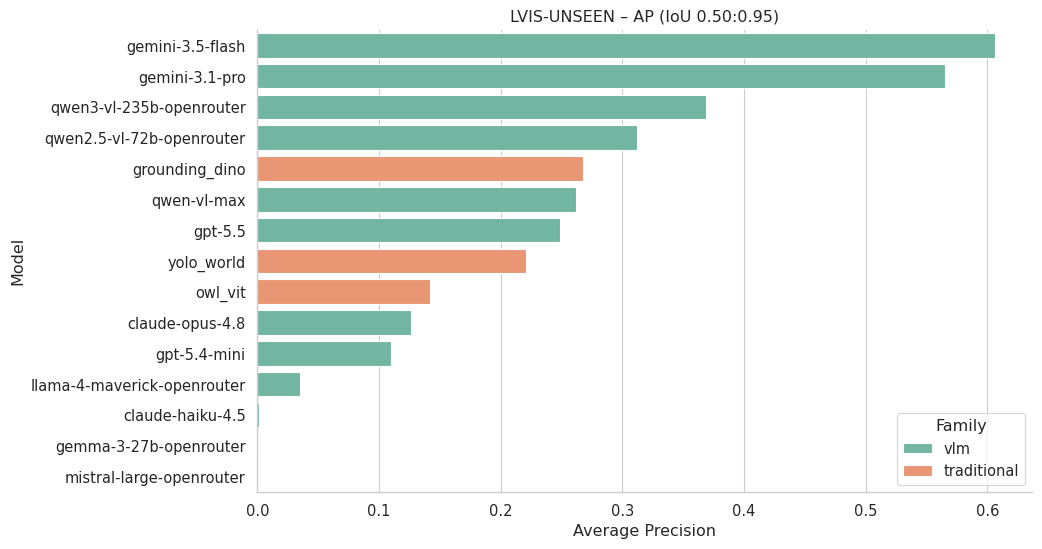

Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_AP@0.5.png
Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_AP@0.5.pdf


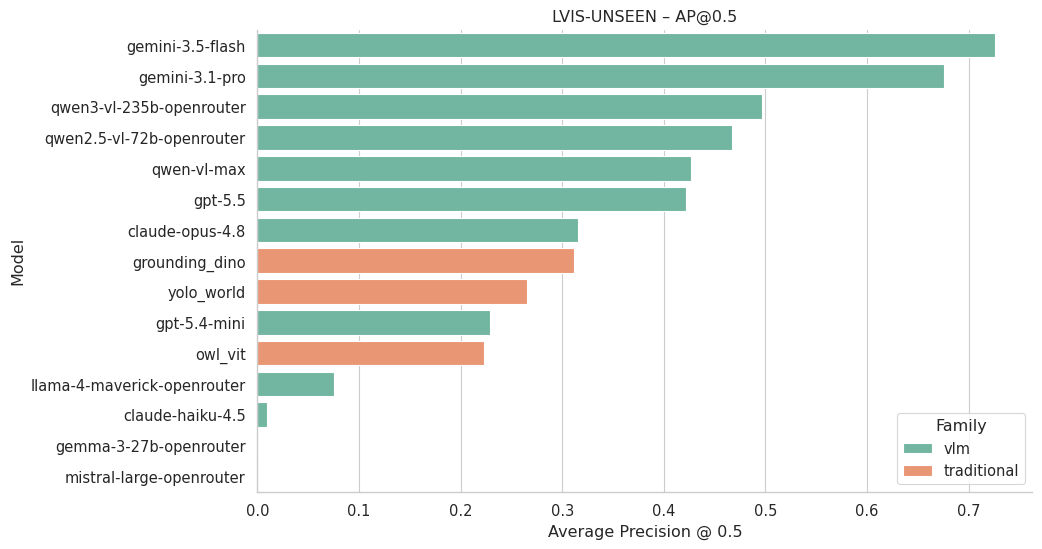

Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_Label_Accuracy.png
Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_Label_Accuracy.pdf


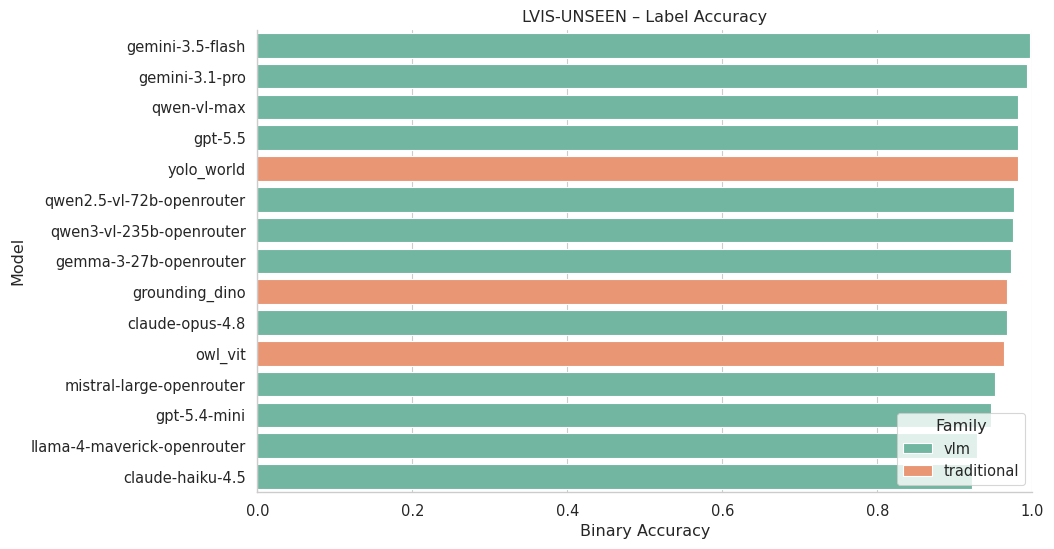

Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_Latency_Statistics.png
Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_Latency_Statistics.pdf


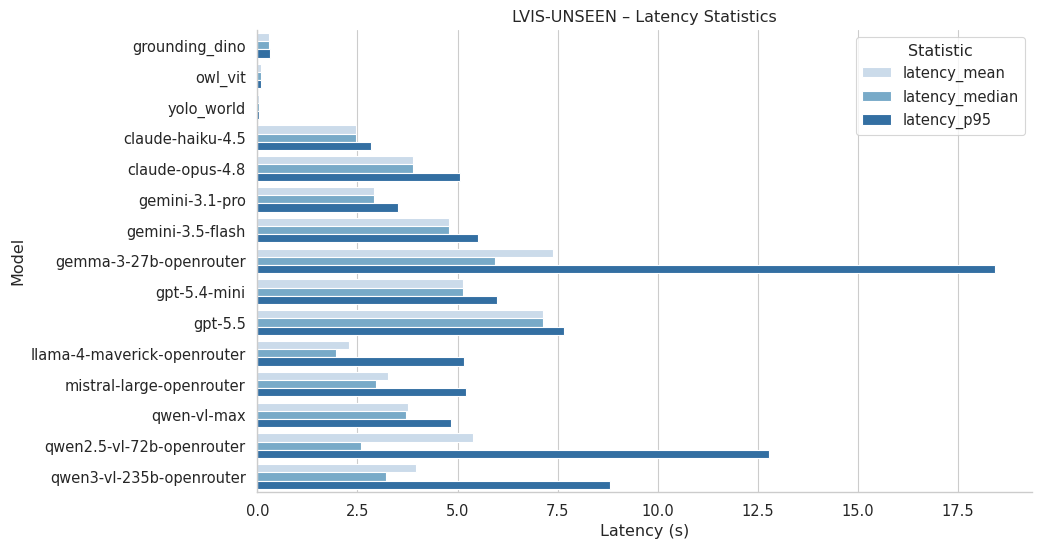

In [4]:
# Full comparison by dataset
for dataset, group in metrics_df.groupby('dataset'):
    display(pd.DataFrame(group))

    fig, ax = plot_bar_metric(
        group,
        metric='AP',
        title=f"{dataset.upper()} – AP (IoU 0.50:0.95)",
        ylabel='Average Precision',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='AP50',
        title=f"{dataset.upper()} – AP@0.5",
        ylabel='Average Precision @ 0.5',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='label_accuracy',
        title=f"{dataset.upper()} – Label Accuracy",
        ylabel='Binary Accuracy',
    )
    if ax is not None:
        ax.set_xlim(left=0, right=1)
        plt.show()

    fig, ax = plot_latency_box(
        group,
        title=f"{dataset.upper()} – Latency Statistics",
    )
    if ax is not None:
        plt.show()


,dataset,model,family,AP,AP50,latency_mean,latency_median,latency_p95,label_accuracy
3,lvis-unseen,claude-haiku-4.5,vlm,0.001469,0.009088,2.474337,2.474337,2.835362,0.922388
4,lvis-unseen,claude-opus-4.8,vlm,0.125929,0.315990,3.878640,3.878640,5.049952,0.966667
5,lvis-unseen,gemini-3.1-pro,vlm,0.564990,0.675897,2.913171,2.913171,3.511172,0.992574
6,lvis-unseen,gemini-3.5-flash,vlm,0.606566,0.726438,4.777280,4.777280,5.515134,0.997506
7,lvis-unseen,gemma-3-27b-openrouter,vlm,0.000244,0.000902,7.375953,5.945155,18.431521,0.971910
8,lvis-unseen,gpt-5.4-mini,vlm,0.109833,0.229294,5.134551,5.134551,5.993908,0.946708
9,lvis-unseen,gpt-5.5,vlm,0.248791,0.421970,7.124613,7.124613,7.655062,0.981818
10,lvis-unseen,llama-4-maverick-openrouter,vlm,0.035422,0.075137,2.279451,1.954386,5.154996,0.928571
11,lvis-unseen,mistral-large-openrouter,vlm,0.000019,0.000157,3.263302,2.973196,5.218282,0.951351
12,lvis-unseen,qwen-vl-max,vlm,0.261593,0.427085,3.762507,3.713166,4.838448,0.981959


Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_AP_(IoU_0.50:0.95).png
Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_AP_(IoU_0.50:0.95).pdf


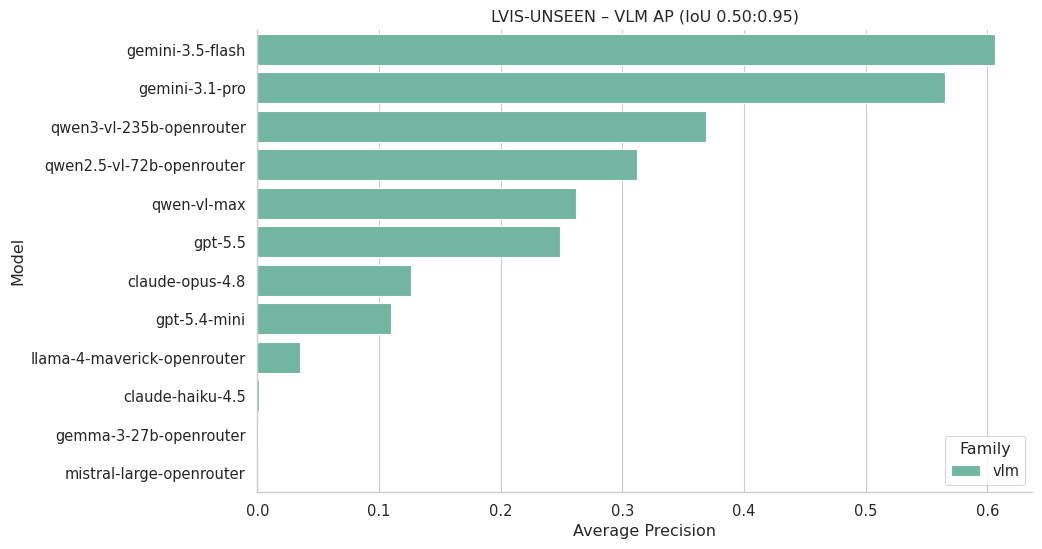

Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_AP@0.5.png
Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_AP@0.5.pdf


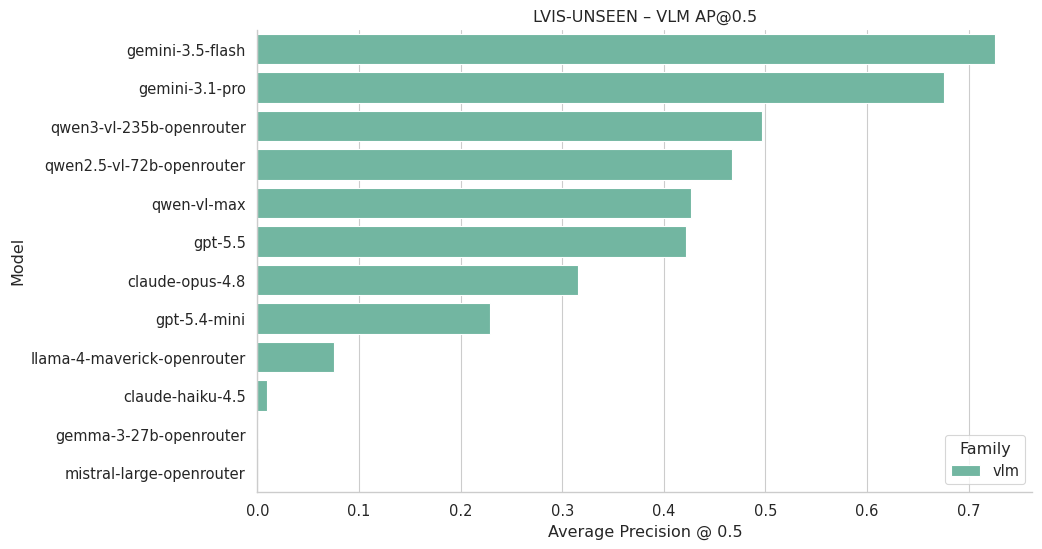

Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_Label_Accuracy.png
Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_Label_Accuracy.pdf


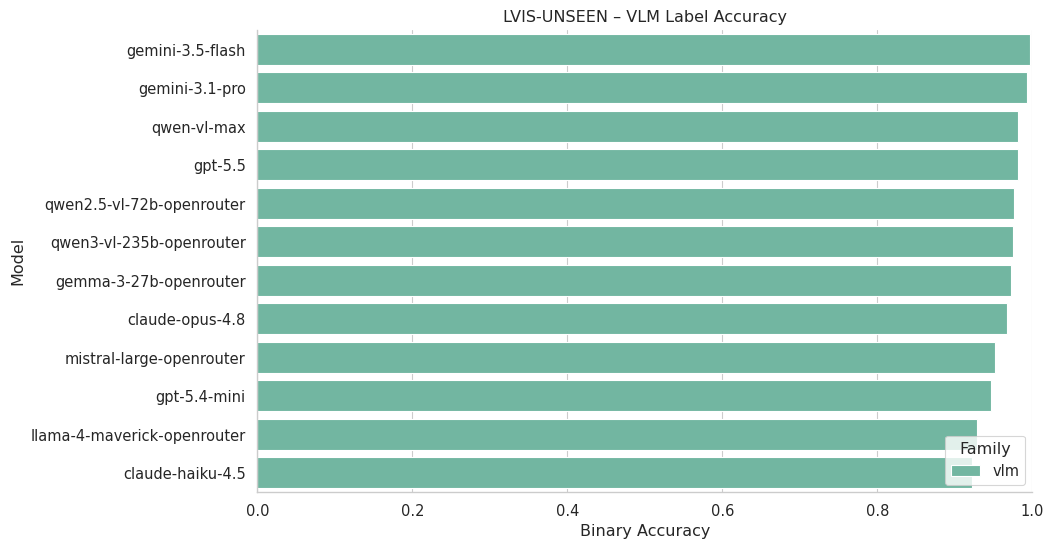

Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_Latency_Statistics.png
Saved: /media/maxim/MX00x/working_dir/zero-shot-detection-benchmark/experiments/results/figures/LVIS-UNSEEN_–_VLM_Latency_Statistics.pdf


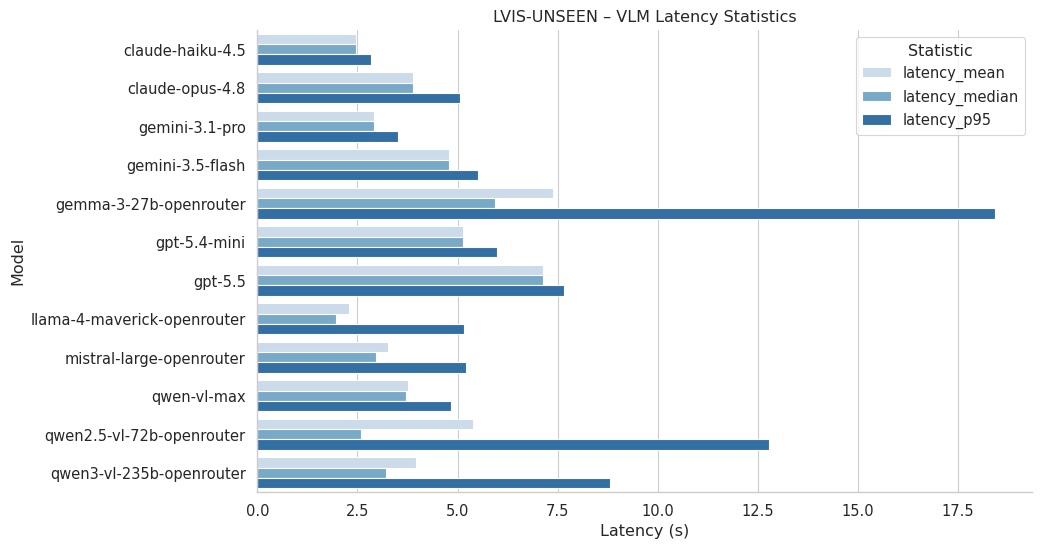

In [5]:
# VLM-only comparison
vlm_df = metrics_df[metrics_df['family'] == 'vlm']
for dataset, group in vlm_df.groupby('dataset'):
    if group.empty:
        continue
    display(pd.DataFrame(group))

    fig, ax = plot_bar_metric(
        group,
        metric='AP',
        title=f"{dataset.upper()} – VLM AP (IoU 0.50:0.95)",
        ylabel='Average Precision',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='AP50',
        title=f"{dataset.upper()} – VLM AP@0.5",
        ylabel='Average Precision @ 0.5',
    )
    if ax is not None:
        plt.show()

    fig, ax = plot_bar_metric(
        group,
        metric='label_accuracy',
        title=f"{dataset.upper()} – VLM Label Accuracy",
        ylabel='Binary Accuracy',
    )
    if ax is not None:
        ax.set_xlim(left=0, right=1)
        plt.show()

    fig, ax = plot_latency_box(
        group,
        title=f"{dataset.upper()} – VLM Latency Statistics",
    )
    if ax is not None:
        plt.show()


## Long-tail Focus (LVIS Unseen)
If your summary JSON contains per-category AP or you want to highlight performance on rare classes, extend the loader to pull those values. The snippet below assumes you augment `metrics_summary.json` with an optional `tail_ap` field.

In [6]:
if "tail_ap" in metrics_df.columns:
    lvis_df = metrics_df[metrics_df["dataset"] == "lvis-unseen"].dropna(subset=["tail_ap"])
    if not lvis_df.empty:
        plot_bar_metric(
            lvis_df,
            metric="tail_ap",
            title="LVIS Unseen – Long-tail AP",
            ylabel="Average Precision (rare classes)",
        )
        plt.show()
    else:
        print("No long-tail AP data found in the summary.")

## Exporting Figures
Use the following helper to save plots in both PNG and PDF formats ready for your manuscript.

In [7]:
def save_figure(fig, name: str, output_dir: Path = PROJECT_ROOT / "results" / "figures"):
    output_dir.mkdir(parents=True, exist_ok=True)
    for ext in ("png", "pdf"):
        fig_path = output_dir / f"{name}.{ext}"
        fig.savefig(fig_path, bbox_inches="tight")
        print(f"Saved: {fig_path}")

After running the plotting cells above, call `save_figure` on any figure you want to embed in the paper.